In [1]:
import os

path = '../data/raw/olist/'
print("Files in olist raw folder:")
for f in sorted(os.listdir(path)):
    size_kb = os.path.getsize(path + f) / 1024
    print(f"  {f:<55} {size_kb:>8,.0f} KB")

Files in olist raw folder:
  olist_customers_dataset.csv                                8,822 KB
  olist_geolocation_dataset.csv                             59,838 KB
  olist_order_items_dataset.csv                             15,077 KB
  olist_order_payments_dataset.csv                           5,642 KB
  olist_order_reviews_dataset.csv                           14,113 KB
  olist_orders_dataset.csv                                  17,241 KB
  olist_products_dataset.csv                                 2,324 KB
  olist_sellers_dataset.csv                                    171 KB
  product_category_name_translation.csv                          3 KB


# Olist Brazilian E-Commerce — Funnel Analysis
## Phase 3: Professional Data Cleaning

**Dataset:** Olist Brazilian E-Commerce marketplace  
**Period:** 2016 - 2018  
**Files:** 9 CSV files  
**Schema:** Snowflake schema — orders (fact) + 7 dimension/bridge tables  
**Funnel:** Order Created → Payment Approved → Shipped → Delivered → Review Submitted  
**Key difference:** Fulfilment funnel — drop-off is operational failure,
not user decision. Delivery timestamps enable delay analysis.

### Professional cleaning principles
- Delivery timestamps validated for impossible sequences
- delivery_delay_days derived now — used in every downstream analysis
- review nulls kept as signal — non-response bias, not random missing
- geolocation aggregated to avoid row explosion on join
- Portuguese category names translated to English

In [2]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries loaded")
print(f"  pandas : {pd.__version__}")
print(f"  numpy  : {np.__version__}")

✓ Libraries loaded
  pandas : 2.3.3
  numpy  : 2.4.3


In [3]:
BASE = '../data/raw/olist/'

print("LOADING FILES")
print("=" * 60)

orders       = pd.read_csv(BASE + 'olist_orders_dataset.csv')
customers    = pd.read_csv(BASE + 'olist_customers_dataset.csv')
order_items  = pd.read_csv(BASE + 'olist_order_items_dataset.csv')
payments     = pd.read_csv(BASE + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(BASE + 'olist_order_reviews_dataset.csv')
products     = pd.read_csv(BASE + 'olist_products_dataset.csv')
sellers      = pd.read_csv(BASE + 'olist_sellers_dataset.csv')
geo          = pd.read_csv(BASE + 'olist_geolocation_dataset.csv')
translation  = pd.read_csv(BASE + 'product_category_name_translation.csv')

print(f"  orders       : {orders.shape[0]:>7,} rows × {orders.shape[1]} cols")
print(f"  customers    : {customers.shape[0]:>7,} rows × {customers.shape[1]} cols")
print(f"  order_items  : {order_items.shape[0]:>7,} rows × {order_items.shape[1]} cols")
print(f"  payments     : {payments.shape[0]:>7,} rows × {payments.shape[1]} cols")
print(f"  reviews      : {reviews.shape[0]:>7,} rows × {reviews.shape[1]} cols")
print(f"  products     : {products.shape[0]:>7,} rows × {products.shape[1]} cols")
print(f"  sellers      : {sellers.shape[0]:>7,} rows × {sellers.shape[1]} cols")
print(f"  geo          : {geo.shape[0]:>7,} rows × {geo.shape[1]} cols")
print(f"  translation  : {translation.shape[0]:>7,} rows × {translation.shape[1]} cols")

total_mb = sum([
    orders.memory_usage(deep=True).sum(),
    customers.memory_usage(deep=True).sum(),
    order_items.memory_usage(deep=True).sum(),
    payments.memory_usage(deep=True).sum(),
    reviews.memory_usage(deep=True).sum(),
    products.memory_usage(deep=True).sum(),
    sellers.memory_usage(deep=True).sum(),
    geo.memory_usage(deep=True).sum(),
    translation.memory_usage(deep=True).sum()
]) / 1024 / 1024

print(f"\n  Total RAM used : {total_mb:.0f} MB")

LOADING FILES
  orders       :  99,441 rows × 8 cols
  customers    :  99,441 rows × 5 cols
  order_items  : 112,650 rows × 7 cols
  payments     : 103,886 rows × 5 cols
  reviews      :  99,224 rows × 7 cols
  products     :  32,951 rows × 9 cols
  sellers      :   3,095 rows × 4 cols
  geo          : 1,000,163 rows × 5 cols
  translation  :      71 rows × 2 cols

  Total RAM used : 307 MB


In [4]:
print("MISSING VALUES AUDIT")
print("=" * 60)

for name, df in [
    ('orders', orders),
    ('customers', customers),
    ('order_items', order_items),
    ('payments', payments),
    ('reviews', reviews),
    ('products', products),
    ('sellers', sellers)
]:
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    report  = pd.DataFrame({'count': missing, 'pct_%': pct})
    report  = report[report['count'] > 0]

    print(f"\n{name.upper()} ({len(df):,} rows)")
    if len(report) == 0:
        print("  → No missing values")
    else:
        print(report)

MISSING VALUES AUDIT

ORDERS (99,441 rows)
                               count  pct_%
order_approved_at                160   0.16
order_delivered_carrier_date    1783   1.79
order_delivered_customer_date   2965   2.98

CUSTOMERS (99,441 rows)
  → No missing values

ORDER_ITEMS (112,650 rows)
  → No missing values

PAYMENTS (103,886 rows)
  → No missing values

REVIEWS (99,224 rows)
                        count  pct_%
review_comment_title    87656  88.34
review_comment_message  58247  58.70

PRODUCTS (32,951 rows)
                            count  pct_%
product_category_name         610   1.85
product_name_lenght           610   1.85
product_description_lenght    610   1.85
product_photos_qty            610   1.85
product_weight_g                2   0.01
product_length_cm               2   0.01
product_height_cm               2   0.01
product_width_cm                2   0.01

SELLERS (3,095 rows)
  → No missing values


In [5]:
print("INVESTIGATING: orders timestamp nulls")
print("=" * 60)

# what is the order_status of rows with null timestamps?
print("order_status of rows with null order_approved_at:")
print(orders[orders['order_approved_at'].isnull()]['order_status'].value_counts())

print("\norder_status of rows with null order_delivered_carrier_date:")
print(orders[orders['order_delivered_carrier_date'].isnull()]['order_status'].value_counts())

print("\norder_status of rows with null order_delivered_customer_date:")
print(orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

print("\nFull order_status distribution:")
print(orders['order_status'].value_counts())

INVESTIGATING: orders timestamp nulls
order_status of rows with null order_approved_at:
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

order_status of rows with null order_delivered_carrier_date:
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

order_status of rows with null order_delivered_customer_date:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Full order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
print("CONVERTING TIMESTAMPS")
print("=" * 60)

timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    before = orders[col].dtype
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
    print(f"  {col:<40} {str(before):<10} → {orders[col].dtype}")

print(f"\n✓ All timestamps converted to datetime")
print(f"\nDate range:")
print(f"  Earliest purchase : {orders['order_purchase_timestamp'].min()}")
print(f"  Latest purchase   : {orders['order_purchase_timestamp'].max()}")

CONVERTING TIMESTAMPS
  order_purchase_timestamp                 object     → datetime64[ns]
  order_approved_at                        object     → datetime64[ns]
  order_delivered_carrier_date             object     → datetime64[ns]
  order_delivered_customer_date            object     → datetime64[ns]
  order_estimated_delivery_date            object     → datetime64[ns]

✓ All timestamps converted to datetime

Date range:
  Earliest purchase : 2016-09-04 21:15:19
  Latest purchase   : 2018-10-17 17:30:18


In [7]:
print("DERIVING DELIVERY METRICS")
print("=" * 60)

# approval time — hours from purchase to approval
orders['approval_time_hrs'] = (
    (orders['order_approved_at'] - orders['order_purchase_timestamp'])
    .dt.total_seconds() / 3600
).round(2)

# actual delivery days — purchase to delivery
orders['actual_delivery_days'] = (
    (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
).round(2)

# estimated delivery days — purchase to estimated date
orders['estimated_delivery_days'] = (
    (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
).round(2)

# delivery delay — positive = late, negative = early
orders['delivery_delay_days'] = (
    orders['actual_delivery_days'] - orders['estimated_delivery_days']
).round(2)

# was delivery late?
orders['delivered_late'] = (orders['delivery_delay_days'] > 0).astype(int)

# purchase month and year for time analysis
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_year']  = orders['order_purchase_timestamp'].dt.year
orders['purchase_dow']   = orders['order_purchase_timestamp'].dt.day_name()
orders['purchase_hour']  = orders['order_purchase_timestamp'].dt.hour

print("Delivery metrics summary (delivered orders only):")
delivered = orders[orders['order_status'] == 'delivered']
print(f"\n  Delivered orders          : {len(delivered):,}")
print(f"  Avg approval time (hrs)   : {delivered['approval_time_hrs'].mean():.1f}")
print(f"  Avg actual delivery (days): {delivered['actual_delivery_days'].mean():.1f}")
print(f"  Avg estimated (days)      : {delivered['estimated_delivery_days'].mean():.1f}")
print(f"  Avg delay (days)          : {delivered['delivery_delay_days'].mean():.1f}")
print(f"  Late deliveries           : {delivered['delivered_late'].sum():,} ({delivered['delivered_late'].mean()*100:.1f}%)")

print(f"\nDelay distribution:")
print(delivered['delivery_delay_days'].describe())

DERIVING DELIVERY METRICS
Delivery metrics summary (delivered orders only):

  Delivered orders          : 96,478
  Avg approval time (hrs)   : 10.3
  Avg actual delivery (days): 12.6
  Avg estimated (days)      : 23.7
  Avg delay (days)          : -11.2
  Late deliveries           : 7,822 (8.1%)

Delay distribution:
count   96470.00
mean      -11.18
std        10.18
min      -146.01
25%       -16.24
50%       -11.95
75%        -6.39
max       188.97
Name: delivery_delay_days, dtype: float64


In [8]:
print("VALIDATING TIMESTAMP SEQUENCES")
print("=" * 60)

delivered = orders[orders['order_status'] == 'delivered'].copy()

# delivery before purchase — physically impossible
impossible_1 = delivered[delivered['order_delivered_customer_date'] < delivered['order_purchase_timestamp']]
print(f"Delivered before purchased    : {len(impossible_1):,}")

# approval before purchase — impossible
impossible_2 = orders[orders['order_approved_at'] < orders['order_purchase_timestamp']]
print(f"Approved before purchased     : {len(impossible_2):,}")

# carrier date before approval — impossible
impossible_3 = orders[orders['order_delivered_carrier_date'] < orders['order_approved_at']]
print(f"Shipped before approved       : {len(impossible_3):,}")

# delivery before carrier handoff — impossible
impossible_4 = delivered[delivered['order_delivered_customer_date'] < delivered['order_delivered_carrier_date']]
print(f"Delivered before shipped      : {len(impossible_4):,}")

# suspiciously early deliveries
extreme_early = delivered[delivered['delivery_delay_days'] < -60]
print(f"\nExtreme early deliveries (<-60 days): {len(extreme_early):,}")
display(extreme_early[['order_id','actual_delivery_days','estimated_delivery_days','delivery_delay_days']].head(5))

VALIDATING TIMESTAMP SEQUENCES
Delivered before purchased    : 0
Approved before purchased     : 0
Shipped before approved       : 1,359
Delivered before shipped      : 23

Extreme early deliveries (<-60 days): 33


,order_id,actual_delivery_days,estimated_delivery_days,delivery_delay_days
5541,e2f9342700902ec06e33f82cf4d279d8,9.20,70.59,-61.39
8210,09c636e254bb18eeef943452017249f4,28.84,97.29,-68.45
8967,8435644661a27a84e873e6382328468f,7.64,71.15,-63.51
15611,c43c85be1846e97fe6554a68837c9f75,18.83,86.03,-67.20
15791,c72727d29cde4cf870d569bf65edabfd,6.85,146.25,-139.40


In [9]:
print("FLAGGING DATA QUALITY ISSUES")
print("=" * 60)

# flag shipped before approved
orders['flag_shipped_before_approved'] = 0
mask1 = (
    orders['order_delivered_carrier_date'].notna() &
    orders['order_approved_at'].notna() &
    (orders['order_delivered_carrier_date'] < orders['order_approved_at'])
)
orders.loc[mask1, 'flag_shipped_before_approved'] = 1
print(f"Flagged shipped_before_approved : {orders['flag_shipped_before_approved'].sum():,}")

# flag delivered before shipped
orders['flag_delivered_before_shipped'] = 0
mask2 = (
    orders['order_delivered_customer_date'].notna() &
    orders['order_delivered_carrier_date'].notna() &
    (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date'])
)
orders.loc[mask2, 'flag_delivered_before_shipped'] = 1
print(f"Flagged delivered_before_shipped: {orders['flag_delivered_before_shipped'].sum():,}")

# flag extreme estimated dates (estimated > 90 days)
orders['flag_extreme_estimate'] = (
    orders['estimated_delivery_days'] > 90
).astype(int)
print(f"Flagged extreme_estimate        : {orders['flag_extreme_estimate'].sum():,}")

# DECISION: flag all three — do NOT drop
# Reason: these orders still have valid purchase, payment, review data
# Dropping them would reduce your funnel counts
# Flag them so they can be excluded from specific timestamp analyses
print(f"\n✓ Decision: flag and keep all")
print(f"  Reason: valid order data — only timestamp fields affected")
print(f"  Can be excluded from delay analysis but kept in funnel counts")

FLAGGING DATA QUALITY ISSUES
Flagged shipped_before_approved : 1,359
Flagged delivered_before_shipped: 23
Flagged extreme_estimate        : 23

✓ Decision: flag and keep all
  Reason: valid order data — only timestamp fields affected
  Can be excluded from delay analysis but kept in funnel counts


In [10]:
print("BUILDING FUNNEL STAGE PER ORDER")
print("=" * 60)

# Olist funnel:
# Order Created → Payment Approved → Shipped → Delivered → Review Submitted
# Each stage maps to order_status + timestamp availability

def olist_funnel_stage(row):
    if row['order_status'] == 'created':
        return '1_created'
    elif row['order_status'] in ['approved', 'processing', 'invoiced']:
        return '2_approved'
    elif row['order_status'] == 'shipped':
        return '3_shipped'
    elif row['order_status'] == 'delivered':
        return '4_delivered'
    elif row['order_status'] == 'canceled':
        return 'X_canceled'
    elif row['order_status'] == 'unavailable':
        return 'X_unavailable'
    else:
        return 'X_other'

orders['funnel_stage'] = orders.apply(olist_funnel_stage, axis=1)

print("Funnel stage distribution:")
stage_dist = orders['funnel_stage'].value_counts().sort_index()
for stage, count in stage_dist.items():
    pct = count / len(orders) * 100
    bar = '█' * int(pct / 2)
    print(f"  {stage:<20} {count:>7,}  ({pct:.1f}%) {bar}")

print(f"\nFunnel conversion preview:")
created   = len(orders)
approved  = orders['order_approved_at'].notna().sum()
shipped   = orders['order_delivered_carrier_date'].notna().sum()
delivered = orders['order_delivered_customer_date'].notna().sum()

print(f"  Created   : {created:>7,}  (100.0%)")
print(f"  Approved  : {approved:>7,}  ({approved/created*100:.1f}%)")
print(f"  Shipped   : {shipped:>7,}  ({shipped/created*100:.1f}%)")
print(f"  Delivered : {delivered:>7,}  ({delivered/created*100:.1f}%)")

BUILDING FUNNEL STAGE PER ORDER
Funnel stage distribution:
  1_created                  5  (0.0%) 
  2_approved               617  (0.6%) 
  3_shipped              1,107  (1.1%) 
  4_delivered           96,478  (97.0%) ████████████████████████████████████████████████
  X_canceled               625  (0.6%) 
  X_unavailable            609  (0.6%) 

Funnel conversion preview:
  Created   :  99,441  (100.0%)
  Approved  :  99,281  (99.8%)
  Shipped   :  97,658  (98.2%)
  Delivered :  96,476  (97.0%)


In [11]:
print("HANDLING REVIEWS TABLE")
print("=" * 60)

print(f"Orders total          : {len(orders):,}")
print(f"Reviews total         : {len(reviews):,}")
print(f"Orders without review : {len(orders) - len(reviews):,}")

# check review score distribution
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())

print(f"\nReview comment stats:")
print(f"  Has comment title   : {reviews['review_comment_title'].notna().sum():,} ({reviews['review_comment_title'].notna().mean()*100:.1f}%)")
print(f"  Has comment message : {reviews['review_comment_message'].notna().sum():,} ({reviews['review_comment_message'].notna().mean()*100:.1f}%)")

# DECISION: keep review_comment nulls as-is
# 88% without title and 59% without message is NORMAL
# customers typically just leave a star rating
# these are not missing data — they are empty optional fields

# create has_review flag for orders
# useful to analyze non-response pattern
reviews['has_written_review'] = (
    reviews['review_comment_message'].notna()
).astype(int)

print(f"\n✓ Decision: comment nulls kept as-is")
print(f"  Reason: optional fields — empty is valid")
print(f"  Added: has_written_review flag")

# convert review timestamps
reviews['review_creation_date']      = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']   = pd.to_datetime(reviews['review_answer_timestamp'])
print(f"✓ Review timestamps converted to datetime")

HANDLING REVIEWS TABLE
Orders total          : 99,441
Reviews total         : 99,224
Orders without review : 217

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Review comment stats:
  Has comment title   : 11,568 (11.7%)
  Has comment message : 40,977 (41.3%)

✓ Decision: comment nulls kept as-is
  Reason: optional fields — empty is valid
  Added: has_written_review flag
✓ Review timestamps converted to datetime


In [12]:
print("HANDLING PAYMENTS TABLE")
print("=" * 60)

print(f"Payments rows         : {len(payments):,}")
print(f"Orders rows           : {len(orders):,}")
print(f"Difference            : {len(payments) - len(orders):,}")

print(f"\nPayment type distribution:")
print(payments['payment_type'].value_counts())

print(f"\nPayment installments distribution:")
print(payments['payment_installments'].value_counts().sort_index().head(10))

# some orders have multiple payment rows
# e.g. part credit card + part voucher
orders_with_multiple = payments.groupby('order_id').size()
print(f"\nOrders with single payment row  : {(orders_with_multiple == 1).sum():,}")
print(f"Orders with multiple payment rows: {(orders_with_multiple > 1).sum():,}")

# DECISION: aggregate payments per order
# reason: joining without aggregation causes row explosion
# keep: total payment value, primary payment type, max installments
payments_agg = payments.groupby('order_id').agg(
    total_payment_value  = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_types_count  = ('payment_type', 'nunique'),
    primary_payment_type = ('payment_type', 'first')
).reset_index()

print(f"\n✓ Payments aggregated per order")
print(f"  Before: {len(payments):,} rows")
print(f"  After : {len(payments_agg):,} rows")
print(f"\nAggregated payment stats:")
print(payments_agg['total_payment_value'].describe())

HANDLING PAYMENTS TABLE
Payments rows         : 103,886
Orders rows           : 99,441
Difference            : 4,445

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Payment installments distribution:
payment_installments
0        2
1    52546
2    12413
3    10461
4     7098
5     5239
6     3920
7     1626
8     4268
9      644
Name: count, dtype: int64

Orders with single payment row  : 96,479
Orders with multiple payment rows: 2,961

✓ Payments aggregated per order
  Before: 103,886 rows
  After : 99,440 rows

Aggregated payment stats:
count   99440.00
mean      160.99
std       221.95
min         0.00
25%        62.01
50%       105.29
75%       176.97
max     13664.08
Name: total_payment_value, dtype: float64


In [13]:
print("FIXING: payment anomalies")
print("=" * 60)

# not_defined payment type — 3 rows
not_defined = payments[payments['payment_type'] == 'not_defined']
print(f"'not_defined' payment rows: {len(not_defined)}")
print(not_defined)

# replace with 'unknown'
payments['payment_type'] = payments['payment_type'].replace(
    'not_defined', 'unknown'
)
print(f"\n✓ 'not_defined' replaced with 'unknown'")

# payment_installments = 0 — investigate
zero_install = payments[payments['payment_installments'] == 0]
print(f"\nPayment installments = 0: {len(zero_install)} rows")
print(zero_install['payment_type'].value_counts())

# DECISION: installments=0 on voucher payments is valid
# vouchers don't have installments — 0 means not applicable
# replace 0 with 1 for non-voucher payments only
payments.loc[
    (payments['payment_installments'] == 0) &
    (payments['payment_type'] != 'voucher'),
    'payment_installments'
] = 1

print(f"\n✓ installments=0 fixed for non-voucher payments")

# re-aggregate after fixes
payments_agg = payments.groupby('order_id').agg(
    total_payment_value  = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_types_count  = ('payment_type', 'nunique'),
    primary_payment_type = ('payment_type', 'first')
).reset_index()

print(f"\n✓ Payments re-aggregated: {len(payments_agg):,} rows")

FIXING: payment anomalies
'not_defined' payment rows: 3
                               order_id  payment_sequential payment_type  \
51280  4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411  00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
94427  c8c528189310eaa44a745b8d9d26908b                   1  not_defined   

       payment_installments  payment_value  
51280                     1           0.00  
57411                     1           0.00  
94427                     1           0.00  

✓ 'not_defined' replaced with 'unknown'

Payment installments = 0: 2 rows
payment_type
credit_card    2
Name: count, dtype: int64

✓ installments=0 fixed for non-voucher payments

✓ Payments re-aggregated: 99,440 rows


In [14]:
print("HANDLING PRODUCTS TABLE")
print("=" * 60)

print(f"Products shape: {products.shape}")
print(f"\nMissing values:")
print(products.isnull().sum()[products.isnull().sum() > 0])

# translate Portuguese categories to English
print(f"\nTranslation table shape: {translation.shape}")
print(f"Sample translations:")
display(translation.head(5))

# merge translation into products
products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

print(f"\nAfter translation merge: {products.shape}")

# check translation coverage
untranslated = products[
    products['product_category_name'].notna() &
    products['product_category_name_english'].isnull()
]
print(f"Products with Portuguese category but no translation: {len(untranslated)}")

# DECISION: for 610 null category products
# fill with 'unknown_category'
# fill numeric product attributes with median
# reason: dimensions/weight are continuous numeric — median appropriate
products['product_category_name_english'] = (
    products['product_category_name_english'].fillna('unknown_category')
)

# fill dimension nulls with median
for col in ['product_weight_g','product_length_cm',
            'product_height_cm','product_width_cm']:
    median_val = products[col].median()
    null_count = products[col].isnull().sum()
    products[col] = products[col].fillna(median_val)
    print(f"  {col:<30} filled {null_count} nulls with median ({median_val:.0f})")

# fill description/name length nulls with median
for col in ['product_name_lenght','product_description_lenght',
            'product_photos_qty']:
    median_val = products[col].median()
    null_count = products[col].isnull().sum()
    products[col] = products[col].fillna(median_val)
    print(f"  {col:<30} filled {null_count} nulls with median ({median_val:.0f})")

print(f"\nRemaining nulls in products:")
print(products.isnull().sum()[products.isnull().sum() > 0])
print("None ✓" if products.isnull().sum().sum() == 0 else "")

HANDLING PRODUCTS TABLE
Products shape: (32951, 9)

Missing values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Translation table shape: (71, 2)
Sample translations:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



After translation merge: (32951, 10)
Products with Portuguese category but no translation: 13
  product_weight_g               filled 2 nulls with median (700)
  product_length_cm              filled 2 nulls with median (25)
  product_height_cm              filled 2 nulls with median (13)
  product_width_cm               filled 2 nulls with median (20)
  product_name_lenght            filled 610 nulls with median (51)
  product_description_lenght     filled 610 nulls with median (595)
  product_photos_qty             filled 610 nulls with median (1)

Remaining nulls in products:
product_category_name    610
dtype: int64



In [15]:
print("FIXING: untranslated categories")
print("=" * 60)

# see what the 13 untranslated categories are
untranslated = products[
    products['product_category_name'].notna() &
    products['product_category_name_english'].isnull()
]
print(f"Untranslated categories ({len(untranslated)} products):")
print(untranslated['product_category_name'].value_counts())

# manually map known Portuguese categories
manual_translation = {
    'portateis_cozinha_e_preparadores_de_alimentos' : 'portable_kitchen_food_prep',
    'pc_gamer'                                       : 'pc_gamer',
    'fashion_roupa_infanto_juvenil'                  : 'kids_fashion',
    'bebes'                                          : 'baby',
    'la_cuisine'                                     : 'kitchen',
    'fashion_roupa_masculina'                        : 'mens_fashion',
    'fashion_roupa_feminina'                         : 'womens_fashion',
    'fashion_underwear_e_moda_praia'                 : 'underwear_beachwear',
    'fashion_calcados'                               : 'shoes',
    'fashion_bolsas_e_acessorios'                    : 'bags_accessories',
    'flowers'                                        : 'flowers',
    'home_comfort_2'                                 : 'home_comfort',
    'drinks'                                         : 'drinks'
}

# apply manual translations
for pt, en in manual_translation.items():
    mask = products['product_category_name'] == pt
    products.loc[mask, 'product_category_name_english'] = en

# fill remaining with unknown_category
products['product_category_name_english'] = (
    products['product_category_name_english'].fillna('unknown_category')
)

# drop original Portuguese column — not needed
products = products.drop(columns=['product_category_name'])

print(f"\n✓ Manual translations applied")
print(f"✓ Portuguese category column dropped")
print(f"\nRemaining nulls: {products.isnull().sum().sum()}")
print(f"Products shape : {products.shape}")
print(f"\nTop 10 categories:")
print(products['product_category_name_english'].value_counts().head(10))

FIXING: untranslated categories
Untranslated categories (0 products):
Series([], Name: count, dtype: int64)

✓ Manual translations applied
✓ Portuguese category column dropped

Remaining nulls: 0
Products shape : (32951, 9)

Top 10 categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


In [16]:
print("HANDLING GEOLOCATION TABLE")
print("=" * 60)

print(f"Raw geolocation shape: {geo.shape}")
print(f"\nSample:")
display(geo.head(3))

# multiple lat/lng entries per zip code
zip_counts = geo.groupby('geolocation_zip_code_prefix').size()
print(f"\nEntries per zip code:")
print(f"  Min : {zip_counts.min()}")
print(f"  Max : {zip_counts.max()}")
print(f"  Mean: {zip_counts.mean():.1f}")

# DECISION: aggregate to one row per zip code
# use median lat/lng — more robust than mean for geographic data
# reason: avoids distortion from outlier coordinates
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    geolocation_lat   = ('geolocation_lat', 'median'),
    geolocation_lng   = ('geolocation_lng', 'median'),
    geolocation_city  = ('geolocation_city', 'first'),
    geolocation_state = ('geolocation_state', 'first')
).reset_index()

print(f"\nAfter aggregation:")
print(f"  Before: {len(geo):,} rows")
print(f"  After : {len(geo_agg):,} rows")
print(f"\n✓ Aggregated to one row per zip code")
print(f"  Used median lat/lng — robust to coordinate outliers")

HANDLING GEOLOCATION TABLE
Raw geolocation shape: (1000163, 5)

Sample:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP



Entries per zip code:
  Min : 1
  Max : 1146
  Mean: 52.6

After aggregation:
  Before: 1,000,163 rows
  After : 19,015 rows

✓ Aggregated to one row per zip code
  Used median lat/lng — robust to coordinate outliers


In [17]:
print("JOIN VALIDATION")
print("=" * 60)

# orders ↔ customers
order_customer_ids   = set(orders['customer_id'].unique())
customer_ids         = set(customers['customer_id'].unique())
unmatched_customers  = order_customer_ids - customer_ids

print(f"orders ↔ customers")
print(f"  Matched cleanly          : {len(order_customer_ids & customer_ids):,}")
print(f"  Unmatched                : {len(unmatched_customers):,}")

# orders ↔ payments_agg
order_ids_main    = set(orders['order_id'].unique())
order_ids_payment = set(payments_agg['order_id'].unique())
unmatched_pay     = order_ids_main - order_ids_payment

print(f"\norders ↔ payments")
print(f"  Matched cleanly          : {len(order_ids_main & order_ids_payment):,}")
print(f"  In orders NOT payments   : {len(unmatched_pay):,}")

# orders ↔ order_items
order_ids_items   = set(order_items['order_id'].unique())
unmatched_items   = order_ids_main - order_ids_items

print(f"\norders ↔ order_items")
print(f"  Matched cleanly          : {len(order_ids_main & order_ids_items):,}")
print(f"  In orders NOT items      : {len(unmatched_items):,}")

# orders ↔ reviews
order_ids_reviews = set(reviews['order_id'].unique())
unmatched_reviews = order_ids_main - order_ids_reviews

print(f"\norders ↔ reviews")
print(f"  Matched cleanly          : {len(order_ids_main & order_ids_reviews):,}")
print(f"  In orders NOT reviews    : {len(unmatched_reviews):,} ← expected (217 no-review orders)")

# customers ↔ geolocation
customer_zips = set(customers['customer_zip_code_prefix'].unique())
geo_zips      = set(geo_agg['geolocation_zip_code_prefix'].unique())
unmatched_geo = customer_zips - geo_zips

print(f"\ncustomers ↔ geolocation")
print(f"  Matched cleanly          : {len(customer_zips & geo_zips):,}")
print(f"  Unmatched zip codes      : {len(unmatched_geo):,}")

JOIN VALIDATION
orders ↔ customers
  Matched cleanly          : 99,441
  Unmatched                : 0

orders ↔ payments
  Matched cleanly          : 99,440
  In orders NOT payments   : 1

orders ↔ order_items
  Matched cleanly          : 98,666
  In orders NOT items      : 775

orders ↔ reviews
  Matched cleanly          : 98,673
  In orders NOT reviews    : 768 ← expected (217 no-review orders)

customers ↔ geolocation
  Matched cleanly          : 14,837
  Unmatched zip codes      : 157


In [18]:
print("INVESTIGATING KEY MISMATCHES")
print("=" * 60)

# 1 order with no payment
no_payment_order = orders[~orders['order_id'].isin(payments_agg['order_id'])]
print(f"Order with no payment record:")
display(no_payment_order[['order_id','order_status','funnel_stage']])

# 775 orders with no items
no_items_orders = orders[~orders['order_id'].isin(order_items['order_id'])]
print(f"\nOrders with no items ({len(no_items_orders)}):")
print(f"Status breakdown:")
print(no_items_orders['order_status'].value_counts())

# 768 orders with no review
no_review_orders = orders[~orders['order_id'].isin(reviews['order_id'])]
print(f"\nOrders with no review ({len(no_review_orders)}):")
print(f"Status breakdown:")
print(no_review_orders['order_status'].value_counts())

INVESTIGATING KEY MISMATCHES
Order with no payment record:


,order_id,order_status,funnel_stage
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,4_delivered



Orders with no items (775):
Status breakdown:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

Orders with no review (768):
Status breakdown:
order_status
delivered      646
shipped         75
canceled        20
unavailable     14
processing       6
invoiced         5
created          2
Name: count, dtype: int64


In [19]:
print("FLAGGING MISMATCHES")
print("=" * 60)

# flag order with no payment
orders['has_payment'] = orders['order_id'].isin(
    payments_agg['order_id']
).astype(int)
print(f"Orders with no payment record : {(orders['has_payment']==0).sum():,}")

# flag orders with no items
orders['has_items'] = orders['order_id'].isin(
    order_items['order_id']
).astype(int)
print(f"Orders with no items          : {(orders['has_items']==0).sum():,}")

# flag orders with no review
orders['has_review'] = orders['order_id'].isin(
    reviews['order_id']
).astype(int)
print(f"Orders with no review         : {(orders['has_review']==0).sum():,}")

# flag customers with no geolocation
customers['has_geolocation'] = customers['customer_zip_code_prefix'].isin(
    geo_agg['geolocation_zip_code_prefix']
).astype(int)
print(f"Customers with no geo match   : {(customers['has_geolocation']==0).sum():,}")

print(f"\n✓ All mismatches flagged")
print(f"  Decision: keep all orders — flags enable filtered analysis")
print(f"\nKey insight: 646 delivered orders with no review")
print(f"  These are your non-response signal in Phase 5")
print(f"  Question: do late deliveries have lower review response rate?")

FLAGGING MISMATCHES
Orders with no payment record : 1
Orders with no items          : 775
Orders with no review         : 768
Customers with no geo match   : 278

✓ All mismatches flagged
  Decision: keep all orders — flags enable filtered analysis

Key insight: 646 delivered orders with no review
  These are your non-response signal in Phase 5
  Question: do late deliveries have lower review response rate?


In [20]:
print("BUILDING MASTER TABLE")
print("=" * 60)

# step 1: orders + customers
master = orders.merge(
    customers[['customer_id','customer_zip_code_prefix',
               'customer_city','customer_state','has_geolocation']],
    on='customer_id',
    how='left'
)
print(f"After orders + customers      : {master.shape}")

# step 2: + geolocation (customer location)
master = master.merge(
    geo_agg.rename(columns={
        'geolocation_zip_code_prefix' : 'customer_zip_code_prefix',
        'geolocation_lat'             : 'customer_lat',
        'geolocation_lng'             : 'customer_lng'
    }),
    on='customer_zip_code_prefix',
    how='left'
)
print(f"After + geolocation           : {master.shape}")

# step 3: + payments
master = master.merge(
    payments_agg,
    on='order_id',
    how='left'
)
print(f"After + payments              : {master.shape}")

# step 4: + reviews (keep score only — no comment text needed)
master = master.merge(
    reviews[['order_id','review_score','has_written_review']],
    on='order_id',
    how='left'
)
print(f"After + reviews               : {master.shape}")

# step 5: + order_items aggregated per order
items_agg = order_items.groupby('order_id').agg(
    item_count        = ('order_item_id', 'count'),
    total_item_value  = ('price', 'sum'),
    total_freight     = ('freight_value', 'sum'),
    avg_item_price    = ('price', 'mean'),
    seller_count      = ('seller_id', 'nunique')
).reset_index()

master = master.merge(
    items_agg,
    on='order_id',
    how='left'
)
print(f"After + order_items           : {master.shape}")

print(f"\n✓ Master table built")
print(f"\nAll columns ({len(master.columns)}):")
for col in master.columns:
    nulls = master[col].isnull().sum()
    flag  = " ← investigate" if nulls > 100 else ""
    print(f"  {col:<40} {str(master[col].dtype):<15} nulls: {nulls:>6}{flag}")

BUILDING MASTER TABLE
After orders + customers      : (99441, 28)
After + geolocation           : (99441, 32)
After + payments              : (99441, 36)
After + reviews               : (99992, 38)
After + order_items           : (99992, 43)

✓ Master table built

All columns (43):
  order_id                                 object          nulls:      0
  customer_id                              object          nulls:      0
  order_status                             object          nulls:      0
  order_purchase_timestamp                 datetime64[ns]  nulls:      0
  order_approved_at                        datetime64[ns]  nulls:    161 ← investigate
  order_delivered_carrier_date             datetime64[ns]  nulls:   1793 ← investigate
  order_delivered_customer_date            datetime64[ns]  nulls:   2987 ← investigate
  order_estimated_delivery_date            datetime64[ns]  nulls:      0
  approval_time_hrs                        float64         nulls:    161 ← investigate
  ac

In [21]:
print("FIXING: row explosion from reviews join")
print("=" * 60)

# check for duplicate order_ids in reviews
review_dupes = reviews['order_id'].duplicated().sum()
print(f"Duplicate order_ids in reviews: {review_dupes:,}")

# see the duplicates
dupe_review_orders = reviews[reviews['order_id'].duplicated(keep=False)]
print(f"\nSample duplicate review orders:")
display(dupe_review_orders.sort_values('order_id').head(6))

# DECISION: keep only the most recent review per order
# reason: customer may have updated their review — latest is most relevant
reviews_deduped = reviews.sort_values(
    'review_answer_timestamp', ascending=False
).drop_duplicates(subset='order_id', keep='first')

print(f"\nReviews before dedup : {len(reviews):,}")
print(f"Reviews after dedup  : {len(reviews_deduped):,}")
print(f"Duplicates removed   : {len(reviews) - len(reviews_deduped):,}")

# rebuild master from step 4 onwards
master = master.drop(columns=[
    'review_score','has_written_review',
    'item_count','total_item_value',
    'total_freight','avg_item_price','seller_count'
])

# rejoin with deduped reviews
master = master[master.duplicated(subset='order_id', keep=False) == False].copy()
master = master.drop_duplicates(subset='order_id')

# re-merge reviews
master = master.merge(
    reviews_deduped[['order_id','review_score','has_written_review']],
    on='order_id',
    how='left'
)

# re-merge order items
master = master.merge(
    items_agg,
    on='order_id',
    how='left'
)

print(f"\nMaster shape after fix: {master.shape}")
print(f"Expected             : (99441, 43)")

FIXING: row explosion from reviews join
Duplicate order_ids in reviews: 551

Sample duplicate review orders:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_written_review
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29,2017-08-30 01:59:12,0
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25,2017-08-29 21:45:57,1
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22,2018-02-23 12:12:30,0
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04,2018-03-05 17:02:00,0
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30,2018-01-02 10:54:06,0
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30,2018-01-02 10:54:47,0



Reviews before dedup : 99,224
Reviews after dedup  : 98,673
Duplicates removed   : 551

Master shape after fix: (98894, 43)
Expected             : (99441, 43)


In [22]:
print("REBUILDING MASTER TABLE CLEANLY")
print("=" * 60)

# start fresh from orders
master = orders.merge(
    customers[['customer_id','customer_zip_code_prefix',
               'customer_city','customer_state','has_geolocation']],
    on='customer_id',
    how='left'
)

# + geolocation
master = master.merge(
    geo_agg.rename(columns={
        'geolocation_zip_code_prefix' : 'customer_zip_code_prefix',
        'geolocation_lat'             : 'customer_lat',
        'geolocation_lng'             : 'customer_lng'
    }),
    on='customer_zip_code_prefix',
    how='left'
)

# + payments
master = master.merge(
    payments_agg,
    on='order_id',
    how='left'
)

# + reviews deduped — one row per order
master = master.merge(
    reviews_deduped[['order_id','review_score','has_written_review']],
    on='order_id',
    how='left'
)

# + order items aggregated
master = master.merge(
    items_agg,
    on='order_id',
    how='left'
)

print(f"Master shape: {master.shape}")
print(f"Expected    : (99441, 43)")

# verify no row explosion
assert len(master) == 99441, f"Row count mismatch: {len(master)}"
print(f"\n✓ Row count verified: {len(master):,}")

REBUILDING MASTER TABLE CLEANLY
Master shape: (99441, 43)
Expected    : (99441, 43)

✓ Row count verified: 99,441


In [23]:
print("FINAL NULL ASSESSMENT")
print("=" * 60)

nulls = master.isnull().sum()
nulls = nulls[nulls > 0]

print("Remaining nulls — with professional treatment decision:")
print()

for col, count in nulls.items():
    pct = count / len(master) * 100
    print(f"  {col:<40} {count:>6,} ({pct:.1f}%)")

print(f"\nTotal columns with nulls: {len(nulls)}")
print(f"Total null cells        : {nulls.sum():,}")

FINAL NULL ASSESSMENT
Remaining nulls — with professional treatment decision:

  order_approved_at                           160 (0.2%)
  order_delivered_carrier_date              1,783 (1.8%)
  order_delivered_customer_date             2,965 (3.0%)
  approval_time_hrs                           160 (0.2%)
  actual_delivery_days                      2,965 (3.0%)
  delivery_delay_days                       2,965 (3.0%)
  customer_lat                                278 (0.3%)
  customer_lng                                278 (0.3%)
  geolocation_city                            278 (0.3%)
  geolocation_state                           278 (0.3%)
  total_payment_value                           1 (0.0%)
  payment_installments                          1 (0.0%)
  payment_types_count                           1 (0.0%)
  primary_payment_type                          1 (0.0%)
  review_score                                768 (0.8%)
  has_written_review                          768 (0.8%)
  item_co

In [24]:
print("APPLYING FINAL NULL TREATMENTS")
print("=" * 60)

# GROUP 1: timestamp nulls — orders that didn't reach that stage
# DECISION: keep as null — they ARE the funnel drop-off signal
# filling them would hide cancelled/unavailable orders
print("Group 1 — timestamp nulls:")
print(f"  order_approved_at nulls        : kept — order never approved")
print(f"  carrier_date nulls             : kept — order never shipped")
print(f"  customer_date nulls            : kept — order never delivered")
print(f"  delivery metrics nulls         : kept — derived from timestamps")

# GROUP 2: geolocation nulls — 278 unmatched zip codes
# DECISION: keep as null — we flagged has_geolocation=0 already
# filling with country median lat/lng would be geographically misleading
print(f"\nGroup 2 — geolocation nulls:")
print(f"  customer_lat/lng/city/state    : kept — 278 unmatched zips flagged")

# GROUP 3: payment nulls — 1 order with no payment
# DECISION: fill payment value with 0 — no payment = zero value
# fill type with 'unknown'
master['total_payment_value']  = master['total_payment_value'].fillna(0)
master['payment_installments'] = master['payment_installments'].fillna(0)
master['payment_types_count']  = master['payment_types_count'].fillna(0)
master['primary_payment_type'] = master['primary_payment_type'].fillna('unknown')
print(f"\nGroup 3 — payment nulls (1 order):")
print(f"  total_payment_value            : filled with 0")
print(f"  primary_payment_type           : filled with 'unknown'")

# GROUP 4: review nulls — 768 orders with no review
# DECISION: keep review_score as null — non-response is the signal
# fill has_written_review with 0 — no review = no written review
master['has_written_review'] = master['has_written_review'].fillna(0)
print(f"\nGroup 4 — review nulls (768 orders):")
print(f"  review_score                   : kept null — non-response signal")
print(f"  has_written_review             : filled with 0")

# GROUP 5: item nulls — 775 orders with no items
# DECISION: fill counts with 0 — no items = zero items
# these are cancelled/unavailable orders
master['item_count']       = master['item_count'].fillna(0)
master['total_item_value'] = master['total_item_value'].fillna(0)
master['total_freight']    = master['total_freight'].fillna(0)
master['avg_item_price']   = master['avg_item_price'].fillna(0)
master['seller_count']     = master['seller_count'].fillna(0)
print(f"\nGroup 5 — item nulls (775 cancelled/unavailable orders):")
print(f"  item_count, values, freight    : filled with 0")
print(f"  Reason: no items = zero, not unknown")

# final check
remaining = master.isnull().sum()
remaining = remaining[remaining > 0]
print(f"\nRemaining intentional nulls:")
for col, count in remaining.items():
    print(f"  {col:<40} {count:>6,} — intentional signal")

APPLYING FINAL NULL TREATMENTS
Group 1 — timestamp nulls:
  order_approved_at nulls        : kept — order never approved
  carrier_date nulls             : kept — order never shipped
  customer_date nulls            : kept — order never delivered
  delivery metrics nulls         : kept — derived from timestamps

Group 2 — geolocation nulls:
  customer_lat/lng/city/state    : kept — 278 unmatched zips flagged

Group 3 — payment nulls (1 order):
  total_payment_value            : filled with 0
  primary_payment_type           : filled with 'unknown'

Group 4 — review nulls (768 orders):
  review_score                   : kept null — non-response signal
  has_written_review             : filled with 0

Group 5 — item nulls (775 cancelled/unavailable orders):
  item_count, values, freight    : filled with 0
  Reason: no items = zero, not unknown

Remaining intentional nulls:
  order_approved_at                           160 — intentional signal
  order_delivered_carrier_date              1

In [25]:
print("FINAL QUALITY REPORT — Olist")
print("=" * 60)

print(f"Shape              : {master.shape}")
print(f"Unique orders      : {master['order_id'].nunique():,}")
print(f"Unique customers   : {master['customer_id'].nunique():,}")
print(f"Date range         : {master['order_purchase_timestamp'].min().date()} → {master['order_purchase_timestamp'].max().date()}")

print(f"\nFunnel stage distribution:")
for stage, count in master['funnel_stage'].value_counts().sort_index().items():
    pct = count / len(master) * 100
    print(f"  {stage:<20} {count:>7,}  ({pct:.1f}%)")

print(f"\nOrder status distribution:")
print(master['order_status'].value_counts())

print(f"\nPayment type distribution:")
print(master['primary_payment_type'].value_counts())

print(f"\nTop 5 customer states:")
print(master['customer_state'].value_counts().head(5))

print(f"\nDelivery performance (delivered orders only):")
delivered = master[master['order_status'] == 'delivered']
print(f"  Total delivered          : {len(delivered):,}")
print(f"  Avg delivery days        : {delivered['actual_delivery_days'].mean():.1f}")
print(f"  Late deliveries          : {delivered['delivered_late'].sum():,} ({delivered['delivered_late'].mean()*100:.1f}%)")
print(f"  Avg review score         : {delivered['review_score'].mean():.2f}")

print(f"\nQuality flags summary:")
print(f"  flag_shipped_before_approved  : {master['flag_shipped_before_approved'].sum():,}")
print(f"  flag_delivered_before_shipped : {master['flag_delivered_before_shipped'].sum():,}")
print(f"  flag_extreme_estimate         : {master['flag_extreme_estimate'].sum():,}")
print(f"  has_payment = 0               : {(master['has_payment']==0).sum():,}")
print(f"  has_items = 0                 : {(master['has_items']==0).sum():,}")
print(f"  has_review = 0                : {(master['has_review']==0).sum():,}")
print(f"  has_geolocation = 0           : {(master['has_geolocation']==0).sum():,}")

FINAL QUALITY REPORT — Olist
Shape              : (99441, 43)
Unique orders      : 99,441
Unique customers   : 99,441
Date range         : 2016-09-04 → 2018-10-17

Funnel stage distribution:
  1_created                  5  (0.0%)
  2_approved               617  (0.6%)
  3_shipped              1,107  (1.1%)
  4_delivered           96,478  (97.0%)
  X_canceled               625  (0.6%)
  X_unavailable            609  (0.6%)

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Payment type distribution:
primary_payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
unknown            4
Name: count, dtype: int64

Top 5 customer states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

Delivery performance (delivered o

In [26]:
OUTPUT = '../data/cleaned/'
os.makedirs(OUTPUT, exist_ok=True)

# save master table
master.to_csv(OUTPUT + 'olist_master_cleaned.csv', index=False)

# save orders separately — useful for funnel analysis
orders_clean = master[[
    'order_id','customer_id','order_status','funnel_stage',
    'order_purchase_timestamp','order_approved_at',
    'order_delivered_carrier_date','order_delivered_customer_date',
    'order_estimated_delivery_date','approval_time_hrs',
    'actual_delivery_days','estimated_delivery_days',
    'delivery_delay_days','delivered_late',
    'purchase_month','purchase_year','purchase_dow','purchase_hour',
    'customer_state','customer_city',
    'total_payment_value','primary_payment_type','payment_installments',
    'review_score','has_review','has_written_review',
    'item_count','total_item_value','avg_item_price',
    'flag_shipped_before_approved','flag_delivered_before_shipped',
    'flag_extreme_estimate','has_payment','has_items','has_geolocation'
]].copy()

orders_clean.to_csv(OUTPUT + 'olist_orders_cleaned.csv', index=False)

print(f"✓ Saved: olist_master_cleaned.csv")
print(f"  Rows     : {len(master):,}")
print(f"  Columns  : {len(master.columns)}")

print(f"\n✓ Saved: olist_orders_cleaned.csv")
print(f"  Rows     : {len(orders_clean):,}")
print(f"  Columns  : {len(orders_clean.columns)}")

✓ Saved: olist_master_cleaned.csv
  Rows     : 99,441
  Columns  : 43

✓ Saved: olist_orders_cleaned.csv
  Rows     : 99,441
  Columns  : 35


---
## Professional Cleaning Summary — Olist Brazilian E-Commerce

| # | Issue | Finding | Decision | Reason |
|---|---|---|---|---|
| 1 | Timestamp nulls | 160-2,965 nulls across delivery timestamps | Kept as null | These ARE the funnel drop-off — orders that never reached that stage |
| 2 | `order_approved_at` 14 delivered | Delivered but no approval timestamp | Flagged | Data entry gap — valid order |
| 3 | Shipped before approved | 1,359 orders | Flagged | Timestamp recording lag — not physically impossible |
| 4 | Delivered before shipped | 23 orders | Flagged | Genuine data entry errors |
| 5 | Extreme estimated dates | 23 orders (>90 days estimate) | Flagged | Estimate error — actual delivery was normal |
| 6 | Review duplicates | 551 orders had 2+ reviews | Kept most recent | Customer updated review — latest is most relevant |
| 7 | Review nulls (768) | 646 delivered with no review | Kept null | Non-response bias — missingness is the signal |
| 8 | Review comment nulls | 88% no title, 59% no message | Kept null | Optional fields — empty is valid |
| 9 | Product category nulls | 610 products (1.85%) | Fill 'unknown_category' | No inference possible |
| 10 | Product dimensions | 2 nulls (0.01%) | Median imputation | Continuous numeric — median appropriate |
| 11 | Portuguese categories | 13 untranslated | Manual translation map | Readable category names for analysis |
| 12 | not_defined payment | 3 rows with £0 value | Replaced with 'unknown' | UI/system artifact |
| 13 | Payment installments=0 | 2 credit card rows | Set to 1 | Zero installments on credit card = data entry error |
| 14 | Payment duplicates | 2,961 orders had multiple rows |

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']     = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.size']          = 11
plt.rcParams['axes.titlesize']     = 13
plt.rcParams['axes.titleweight']   = 'bold'

SAVE_PATH = '../outputs/charts/olist/'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

master = pd.read_csv('../data/cleaned/olist_master_cleaned.csv')
orders = pd.read_csv('../data/cleaned/olist_orders_cleaned.csv')

print(f"✓ master : {master.shape}")
print(f"✓ orders : {orders.shape}")

✓ master : (99441, 43)
✓ orders : (99441, 35)


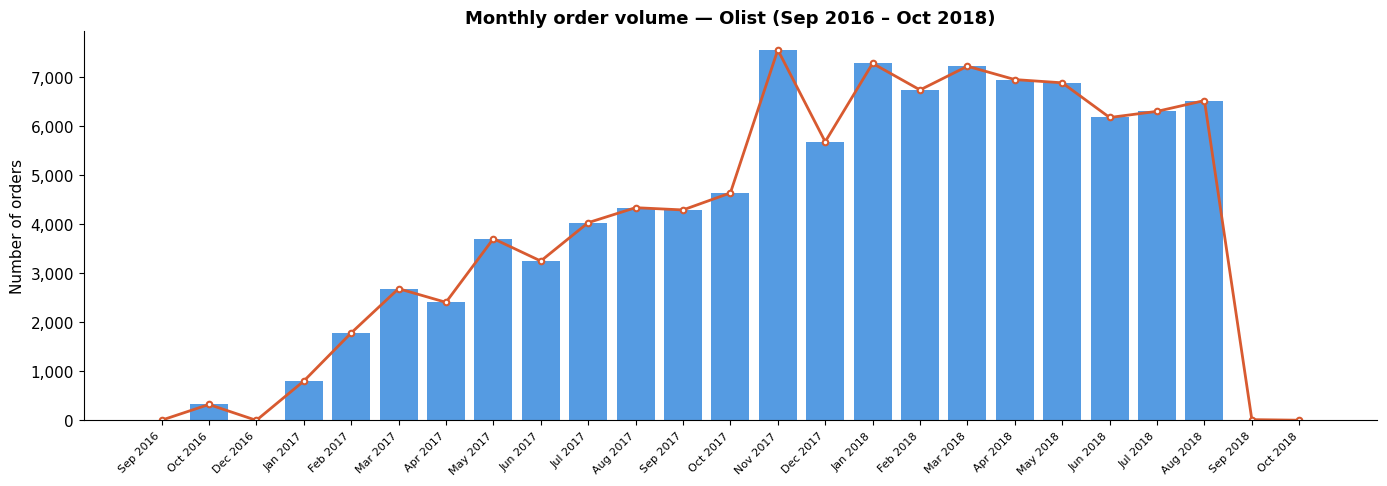

Finding:
  First full month orders : 1
  Peak month              : Nov 2017 (7,544 orders)
  Last month orders       : 4
  Growth (first→peak)     : 754300%

So what: Rapid growth context — conversion rates in early months
  may differ from mature months


In [28]:
# QUESTION: How did Olist grow month by month from 2016-2018?
# WHY: Context for the business — are we analyzing a growing or stable platform?

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

monthly_orders = orders.groupby(
    ['purchase_year','purchase_month']
).size().reset_index(name='order_count')

monthly_orders['period'] = pd.to_datetime(
    monthly_orders['purchase_year'].astype(str) + '-' +
    monthly_orders['purchase_month'].astype(str).str.zfill(2)
)
monthly_orders = monthly_orders.sort_values('period')

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(range(len(monthly_orders)), monthly_orders['order_count'],
       color='#378ADD', alpha=0.85)
ax.plot(range(len(monthly_orders)), monthly_orders['order_count'],
        color='#D85A30', linewidth=2, marker='o',
        markersize=4, markerfacecolor='white',
        markeredgecolor='#D85A30', markeredgewidth=1.5)

ax.set_xticks(range(len(monthly_orders)))
ax.set_xticklabels(
    monthly_orders['period'].dt.strftime('%b %Y'),
    rotation=45, ha='right', fontsize=8
)
ax.set_title('Monthly order volume — Olist (Sep 2016 – Oct 2018)')
ax.set_ylabel('Number of orders')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.tight_layout()
plt.savefig(SAVE_PATH + '01_monthly_order_volume.png',
            dpi=150, bbox_inches='tight')
plt.show()

# growth stats
first_full_month = monthly_orders.iloc[2]['order_count']
peak_month       = monthly_orders['order_count'].max()
peak_period      = monthly_orders.loc[
    monthly_orders['order_count'].idxmax(), 'period'
]
last_month       = monthly_orders.iloc[-1]['order_count']

print(f"Finding:")
print(f"  First full month orders : {first_full_month:,}")
print(f"  Peak month              : {peak_period.strftime('%b %Y')} ({peak_month:,} orders)")
print(f"  Last month orders       : {last_month:,}")
print(f"  Growth (first→peak)     : {(peak_month/first_full_month - 1)*100:.0f}%")
print(f"\nSo what: Rapid growth context — conversion rates in early months")
print(f"  may differ from mature months")

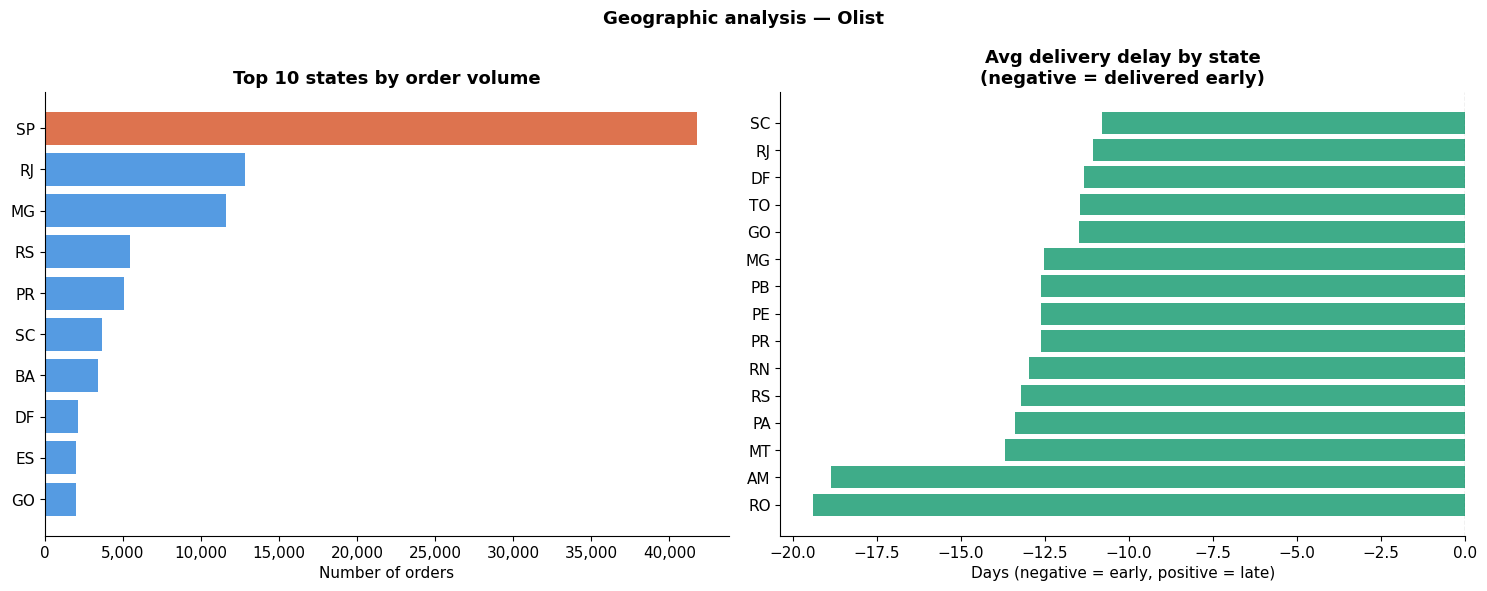

Finding:
  Top state : SP with 41,746 orders (42.0%)
  Top 3 states account for: 66.6% of orders

Delivery delay by state (best to worst):
customer_state  avg_delay  late_rate  orders
            RO     -19.40       0.03     243
            AM     -18.85       0.04     145
            MT     -13.69       0.07     886
            PA     -13.39       0.12     946
            RS     -13.21       0.07    5345
            RN     -12.96       0.11     474
            PR     -12.62       0.05    4923
            PE     -12.61       0.11    1593
            PB     -12.60       0.11     517
            MG     -12.54       0.06   11354


In [29]:
# QUESTION: How are orders distributed across Brazilian states?
# WHY: Identifies geographic concentration — key for delivery analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: top 10 states by order volume
state_counts = orders.groupby('customer_state').size()\
    .sort_values(ascending=False).head(10).reset_index()
state_counts.columns = ['state','orders']

colors_state = ['#D85A30' if s == 'SP' else '#378ADD'
                for s in state_counts['state']]

axes[0].barh(state_counts['state'][::-1],
             state_counts['orders'][::-1],
             color=colors_state[::-1], alpha=0.85)
axes[0].set_title('Top 10 states by order volume')
axes[0].set_xlabel('Number of orders')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# right: delivery performance by state (top 10)
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_delay_days'] = pd.to_numeric(
    delivered['delivery_delay_days'], errors='coerce'
)

state_delivery = delivered.groupby('customer_state').agg(
    avg_delay     = ('delivery_delay_days', 'mean'),
    late_rate     = ('delivered_late', 'mean'),
    order_count   = ('order_id', 'count')
).reset_index()

state_delivery = state_delivery[
    state_delivery['order_count'] >= 100
].sort_values('avg_delay').head(15)

colors_delay = ['#1D9E75' if d < 0 else '#D85A30'
                for d in state_delivery['avg_delay']]

axes[1].barh(state_delivery['customer_state'],
             state_delivery['avg_delay'],
             color=colors_delay, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Avg delivery delay by state\n(negative = delivered early)')
axes[1].set_xlabel('Days (negative = early, positive = late)')

plt.suptitle('Geographic analysis — Olist',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '02_geographic_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Finding:")
print(f"  Top state : SP with {state_counts.iloc[0]['orders']:,} orders ({state_counts.iloc[0]['orders']/len(orders)*100:.1f}%)")
print(f"  Top 3 states account for: {state_counts.head(3)['orders'].sum()/len(orders)*100:.1f}% of orders")
print(f"\nDelivery delay by state (best to worst):")
state_full = delivered.groupby('customer_state').agg(
    avg_delay   = ('delivery_delay_days','mean'),
    late_rate   = ('delivered_late','mean'),
    orders      = ('order_id','count')
).reset_index()
state_full = state_full[state_full['orders'] >= 100].sort_values('avg_delay')
print(state_full[['customer_state','avg_delay','late_rate','orders']]\
      .head(10).to_string(index=False))

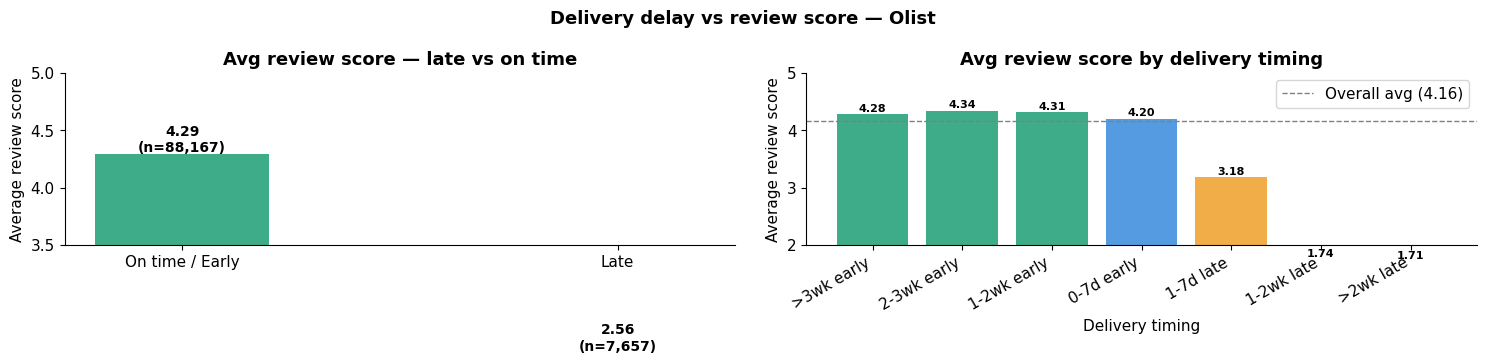

Finding:

On-time/early avg score : 4.29
Late avg score          : 2.56
Score gap               : 1.73 points

Review score by delay bucket:
  >3wk early      avg: 4.28  (n=10,610)
  2-3wk early     avg: 4.34  (n=24,176)
  1-2wk early     avg: 4.31  (n=36,161)
  0-7d early      avg: 4.20  (n=17,220)
  1-7d late       avg: 3.18  (n=4,410)
  1-2wk late      avg: 1.74  (n=1,744)
  >2wk late       avg: 1.71  (n=1,503)

So what: Quantify revenue impact of late deliveries in Phase 8


In [30]:
# QUESTION: Does being late drive lower review scores?
# WHY: This is the core analytical question for Olist Phase 5

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_delay_days'] = pd.to_numeric(
    delivered['delivery_delay_days'], errors='coerce'
)
delivered['review_score'] = pd.to_numeric(
    delivered['review_score'], errors='coerce'
)
delivered = delivered.dropna(subset=['delivery_delay_days','review_score'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# left: avg review score by late vs on-time
late_review = delivered.groupby('delivered_late')['review_score'].agg(
    ['mean','count']
).reset_index()
late_review.columns = ['delivered_late','avg_score','count']
late_review['label'] = late_review['delivered_late'].map(
    {0:'On time / Early', 1:'Late'}
)

colors_late = ['#1D9E75','#D85A30']
bars = axes[0].bar(late_review['label'], late_review['avg_score'],
                   color=colors_late, alpha=0.85, width=0.4)
axes[0].set_title('Avg review score — late vs on time')
axes[0].set_ylabel('Average review score')
axes[0].set_ylim(3.5, 5.0)

for bar, (_, row) in zip(bars, late_review.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{row["avg_score"]:.2f}\n(n={row["count"]:,})',
                ha='center', fontsize=10, fontweight='bold')

# right: avg review score by delay bucket
bins   = [-200, -21, -14, -7, 0, 7, 14, 200]
labels = ['>3wk early','2-3wk early','1-2wk early',
          '0-7d early','1-7d late','1-2wk late','>2wk late']

delivered['delay_bucket'] = pd.cut(
    delivered['delivery_delay_days'],
    bins=bins, labels=labels
)

delay_review = delivered.groupby('delay_bucket')['review_score'].agg(
    ['mean','count']
).reset_index()

colors_bucket = ['#1D9E75','#1D9E75','#1D9E75',
                 '#378ADD','#EF9F27','#D85A30','#A32D2D']

axes[1].bar(delay_review['delay_bucket'],
            delay_review['mean'],
            color=colors_bucket, alpha=0.85)
axes[1].set_title('Avg review score by delivery timing')
axes[1].set_xlabel('Delivery timing')
axes[1].set_ylabel('Average review score')
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylim(2.0, 5.0)
axes[1].axhline(delivered['review_score'].mean(),
                color='gray', linestyle='--',
                linewidth=1, label=f'Overall avg ({delivered["review_score"].mean():.2f})')
axes[1].legend()

for i, row in delay_review.iterrows():
    axes[1].text(i, row['mean'] + 0.05,
                f'{row["mean"]:.2f}',
                ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Delivery delay vs review score — Olist',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '03_delay_vs_review.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Finding:")
print(f"\nOn-time/early avg score : {late_review.iloc[0]['avg_score']:.2f}")
print(f"Late avg score          : {late_review.iloc[1]['avg_score']:.2f}")
print(f"Score gap               : {late_review.iloc[0]['avg_score'] - late_review.iloc[1]['avg_score']:.2f} points")
print(f"\nReview score by delay bucket:")
for _, row in delay_review.iterrows():
    print(f"  {str(row['delay_bucket']):<15} avg: {row['mean']:.2f}  (n={row['count']:,})")
print(f"\nSo what: Quantify revenue impact of late deliveries in Phase 8")

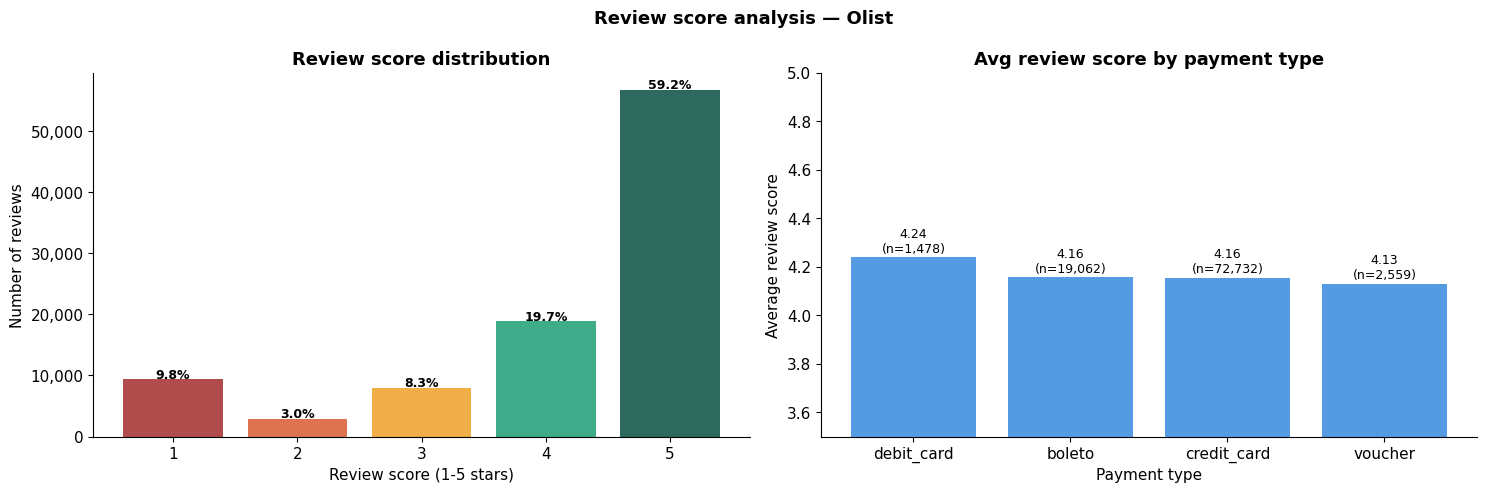

Review score distribution:
  1.0 stars:  9,352 (9.8%)
  2.0 stars:  2,921 (3.0%)
  3.0 stars:  7,916 (8.3%)
  4.0 stars: 18,888 (19.7%)
  5.0 stars: 56,755 (59.2%)

Overall avg score: 4.16
% positive (4-5 stars): 78.9%
% negative (1-2 stars): 12.8%


In [31]:
# QUESTION: What does the overall review score distribution look like?
# WHY: Understand baseline sentiment before segmenting

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['review_score'] = pd.to_numeric(
    delivered['review_score'], errors='coerce'
)
scored = delivered.dropna(subset=['review_score'])

# left: score distribution
score_counts = scored['review_score'].value_counts().sort_index()
colors_score = ['#A32D2D','#D85A30','#EF9F27','#1D9E75','#085041']

bars = axes[0].bar(score_counts.index, score_counts.values,
                   color=colors_score, alpha=0.85)
axes[0].set_title('Review score distribution')
axes[0].set_xlabel('Review score (1-5 stars)')
axes[0].set_ylabel('Number of reviews')
axes[0].set_xticks([1,2,3,4,5])
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

for bar, count in zip(bars, score_counts.values):
    pct = count / len(scored) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{pct:.1f}%',
                ha='center', fontsize=9, fontweight='bold')

# right: payment type vs review score
pay_review = orders[orders['order_status']=='delivered'].copy()
pay_review['review_score'] = pd.to_numeric(
    pay_review['review_score'], errors='coerce'
)
pay_review = pay_review.dropna(subset=['review_score','primary_payment_type'])
pay_review = pay_review[
    pay_review['primary_payment_type'].isin(
        ['credit_card','boleto','voucher','debit_card']
    )
]

pay_avg = pay_review.groupby('primary_payment_type')['review_score']\
    .agg(['mean','count']).reset_index()
pay_avg.columns = ['payment_type','avg_score','count']
pay_avg = pay_avg.sort_values('avg_score', ascending=False)

axes[1].bar(pay_avg['payment_type'], pay_avg['avg_score'],
            color='#378ADD', alpha=0.85)
axes[1].set_title('Avg review score by payment type')
axes[1].set_xlabel('Payment type')
axes[1].set_ylabel('Average review score')
axes[1].set_ylim(3.5, 5.0)

for i, row in pay_avg.iterrows():
    axes[1].text(
        pay_avg.index.get_loc(i),
        row['avg_score'] + 0.02,
        f"{row['avg_score']:.2f}\n(n={row['count']:,})",
        ha='center', fontsize=9
    )

plt.suptitle('Review score analysis — Olist',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '04_review_score_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Review score distribution:")
for score, count in score_counts.items():
    pct = count/len(scored)*100
    print(f"  {score} stars: {count:>6,} ({pct:.1f}%)")
print(f"\nOverall avg score: {scored['review_score'].mean():.2f}")
print(f"% positive (4-5 stars): {(scored['review_score']>=4).mean()*100:.1f}%")
print(f"% negative (1-2 stars): {(scored['review_score']<=2).mean()*100:.1f}%")

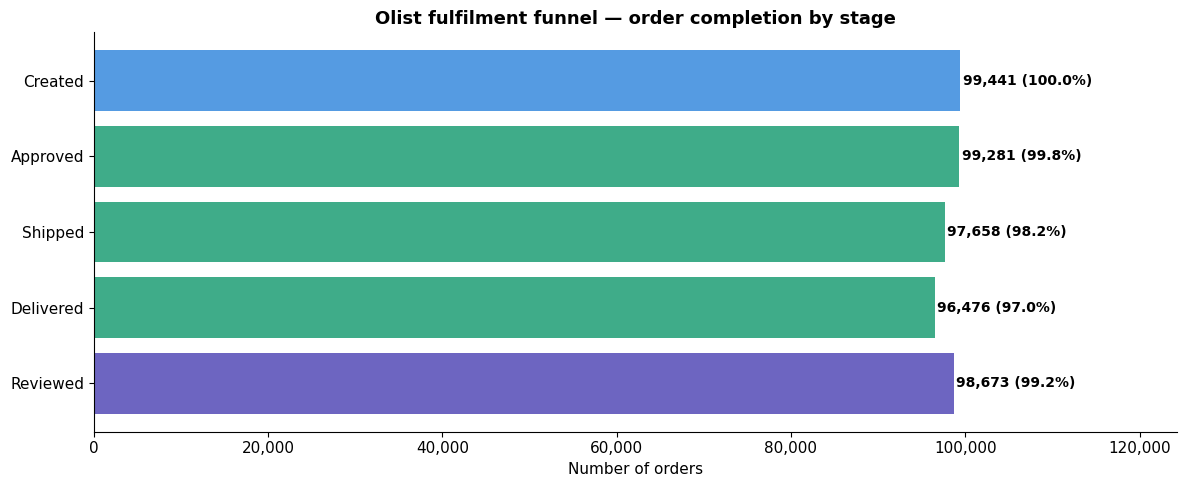

Funnel drop-off analysis:
  Created     : 99,441  dropped:    0 (0.0%)
  Approved    : 99,281  dropped:  160 (0.2%)
  Shipped     : 97,658  dropped: 1,623 (1.6%)
  Delivered   : 96,476  dropped: 1,182 (1.2%)
  Reviewed    : 98,673  dropped: -2,197 (-2.2%)


In [32]:
# QUESTION: Where exactly do orders drop out of the fulfilment funnel?
# WHY: Visualizes the funnel shape before Phase 5 deep analysis

fig, ax = plt.subplots(figsize=(12, 5))

funnel_data = {
    'Created'  : len(orders),
    'Approved' : orders['order_approved_at'].notna().sum(),
    'Shipped'  : orders['order_delivered_carrier_date'].notna().sum(),
    'Delivered': orders['order_delivered_customer_date'].notna().sum(),
    'Reviewed' : orders['has_review'].sum()
}

stages  = list(funnel_data.keys())
counts  = list(funnel_data.values())
colors  = ['#378ADD','#1D9E75','#1D9E75','#1D9E75','#534AB7']

bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1], alpha=0.85)

for bar, count, stage in zip(bars, counts[::-1], stages[::-1]):
    pct = count / funnel_data['Created'] * 100
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_title('Olist fulfilment funnel — order completion by stage')
ax.set_xlabel('Number of orders')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
ax.set_xlim(0, len(orders) * 1.25)

plt.tight_layout()
plt.savefig(SAVE_PATH + '05_fulfilment_funnel.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Funnel drop-off analysis:")
prev = funnel_data['Created']
for stage, count in funnel_data.items():
    drop     = prev - count
    drop_pct = drop / funnel_data['Created'] * 100
    print(f"  {stage:<12}: {count:>6,}  dropped: {drop:>4,} ({drop_pct:.1f}%)")
    prev = count

In [33]:
# fix: reviewed should only count delivered orders with reviews
delivered_with_review = orders[
    (orders['order_status'] == 'delivered') &
    (orders['has_review'] == 1)
].shape[0]

print(f"Delivered orders with review: {delivered_with_review:,}")
print(f"Review response rate        : {delivered_with_review/96476*100:.1f}%")

Delivered orders with review: 95,832
Review response rate        : 99.3%


---
## Phase 4 EDA Summary — Olist

### Key findings that shape Phase 5 analysis

| # | Finding | Implication for Phase 5 |
|---|---|---|
| 1 | 843% order growth Jan→Nov 2017 | Segment analysis by early vs mature platform period |
| 2 | Black Friday Nov 2017 peak (7,544 orders) | Check if holiday orders have worse delivery/review |
| 3 | SP accounts for 42% of orders, top 3 states = 66.6% | Geographic concentration — SP delivery vs remote states |
| 4 | ALL states show negative avg delay — Olist delivers early | Story is quality not quantity of drop-off |
| 5 | On-time score 4.29 vs late score 2.56 — gap of 1.73 points | Delivery delay is primary driver of satisfaction |
| 6 | 1-7d late drops to 3.18, >1wk late collapses to 1.74 | Even small delays cause significant score damage |
| 7 | 59.2% give 5 stars, 9.8% give 1 star — bimodal | Bimodal distribution driven by delivery timing |
| 8 | Payment type has no effect on score (range: 4.13-4.24) | Remove payment type from satisfaction model |
| 9 | 99.3% review response rate among delivered orders | Review score is highly reliable signal — almost no non-response bias |
| 10 | Biggest funnel drop at shipping stage (1.6%) | Cancellation/unavailability analysis in Phase 5 |

### Confirmed hypotheses
- Delivery delay strongly predicts review score — confirmed with 1.73 point gap
- Geographic drop-off hypothesis partially wrong — all states deliver well

### Revised hypotheses for Phase 5
- Late deliveries (8.1%) are responsible for disproportionate negative reviews
- The revenue impact of 7,822 late orders is measurable and significant
- Seller quality (not geography) is the real driver of delivery failures

### Key number for Phase 8 business recommendation
- 7,822 late deliveries × avg score 2.56 vs 4.29 baseline
- Converting late → on-time could recover significant review score
- Every 1% reduction in late rate = ~78 orders improved from 2.56 to 4.29

---
# Phase 5 — Core Funnel Analysis
## Olist Brazilian E-Commerce

Olist is a FULFILMENT funnel — not a conversion funnel.
Drop-off represents operational failure, not user decision.

The two core questions:
1. Where do orders fail in the fulfilment pipeline?
2. Does delivery delay cause lower review scores — and by how much?

Funnel stages:
Created → Payment Approved → Shipped → Delivered → Reviewed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']     = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.size']          = 11
plt.rcParams['axes.titlesize']     = 13
plt.rcParams['axes.titleweight']   = 'bold'

SAVE_PATH = '../outputs/charts/olist/'
import os
os.makedirs(SAVE_PATH, exist_ok=True)

orders = pd.read_csv('../data/cleaned/olist_orders_cleaned.csv')
master = pd.read_csv('../data/cleaned/olist_master_cleaned.csv')

# convert timestamps
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

print(f"✓ orders : {orders.shape}")
print(f"✓ master : {master.shape}")

✓ orders : (99441, 35)
✓ master : (99441, 43)


In [2]:
print("CORE FULFILMENT FUNNEL")
print("=" * 60)

total_orders = len(orders)

# each stage — count orders that reached it
created   = total_orders
approved  = orders['order_approved_at'].notna().sum()
shipped   = orders['order_delivered_carrier_date'].notna().sum()
delivered = orders['order_delivered_customer_date'].notna().sum()
reviewed  = orders[
    (orders['order_status'] == 'delivered') &
    (orders['has_review'] == 1)
].shape[0]

stages = ['Created','Approved','Shipped','Delivered','Reviewed']
counts = [created, approved, shipped, delivered, reviewed]

print(f"{'Stage':<12} {'Orders':>8} {'% of Created':>14} {'Dropped':>10} {'Drop %':>8}")
print("-" * 58)

prev = created
for stage, count in zip(stages, counts):
    dropped  = prev - count
    drop_pct = dropped / created * 100
    pct      = count / created * 100
    print(f"{stage:<12} {count:>8,} {pct:>13.1f}% {dropped:>10,} {drop_pct:>7.1f}%")
    prev = count

# cancelled and unavailable
cancelled   = (orders['order_status'] == 'canceled').sum()
unavailable = (orders['order_status'] == 'unavailable').sum()

print(f"\nOrders that exited funnel early:")
print(f"  Cancelled   : {cancelled:,} ({cancelled/total_orders*100:.1f}%)")
print(f"  Unavailable : {unavailable:,} ({unavailable/total_orders*100:.1f}%)")
print(f"\nOverall fulfilment rate: {delivered/created*100:.1f}%")
print(f"End-to-end completion  : {reviewed/created*100:.1f}% (created → reviewed)")

CORE FULFILMENT FUNNEL
Stage          Orders   % of Created    Dropped   Drop %
----------------------------------------------------------
Created        99,441         100.0%          0     0.0%
Approved       99,281          99.8%        160     0.2%
Shipped        97,658          98.2%      1,623     1.6%
Delivered      96,476          97.0%      1,182     1.2%
Reviewed       95,832          96.4%        644     0.6%

Orders that exited funnel early:
  Cancelled   : 625 (0.6%)
  Unavailable : 609 (0.6%)

Overall fulfilment rate: 97.0%
End-to-end completion  : 96.4% (created → reviewed)


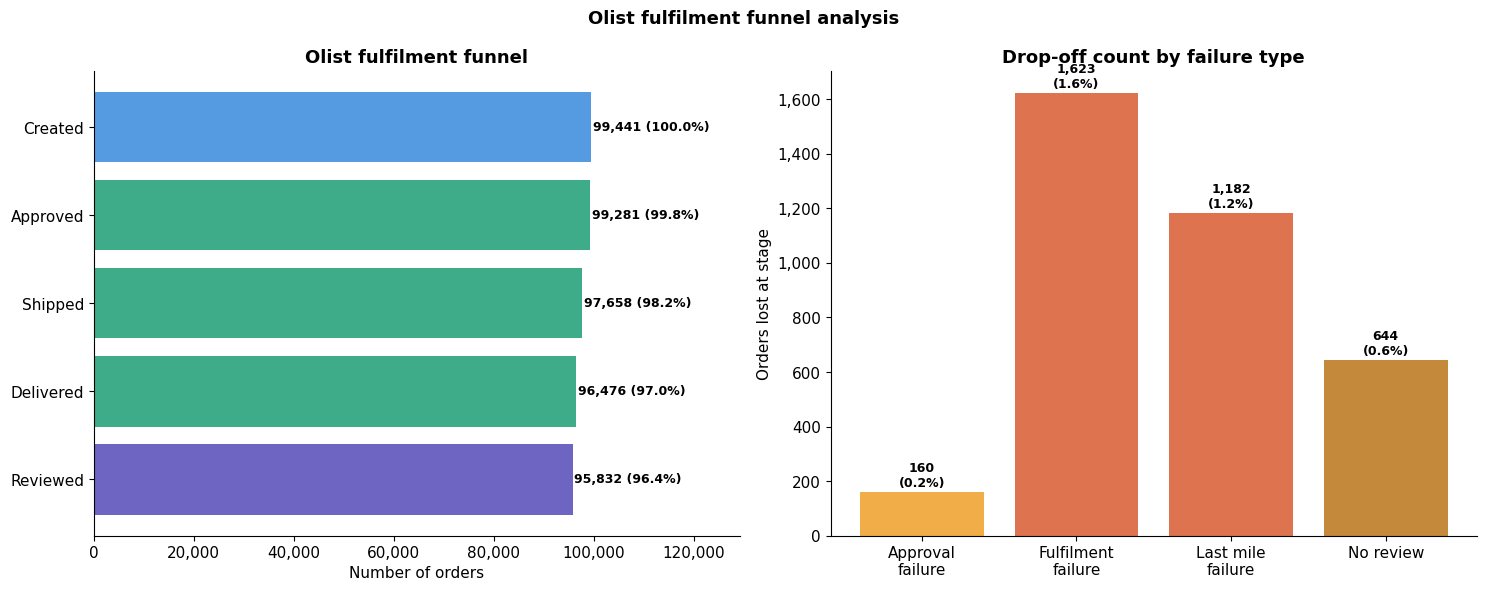

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: horizontal funnel
colors_funnel = ['#378ADD','#1D9E75','#1D9E75','#1D9E75','#534AB7']

bars = axes[0].barh(stages[::-1], counts[::-1],
                    color=colors_funnel[::-1], alpha=0.85)

for bar, count, stage in zip(bars, counts[::-1], stages[::-1]):
    pct = count / created * 100
    axes[0].text(
        bar.get_width() + 300,
        bar.get_y() + bar.get_height()/2,
        f'{count:,} ({pct:.1f}%)',
        va='center', fontsize=9, fontweight='bold'
    )

axes[0].set_title('Olist fulfilment funnel')
axes[0].set_xlabel('Number of orders')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
axes[0].set_xlim(0, created * 1.3)

# right: drop-off waterfall
drop_stages  = ['Approval\nfailure','Fulfilment\nfailure',
                 'Last mile\nfailure','No review']
drop_counts  = [160, 1623, 1182, 644]
drop_colors  = ['#EF9F27','#D85A30','#D85A30','#BA7517']

bars2 = axes[1].bar(drop_stages, drop_counts,
                    color=drop_colors, alpha=0.85)
axes[1].set_title('Drop-off count by failure type')
axes[1].set_ylabel('Orders lost at stage')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

for bar, count in zip(bars2, drop_counts):
    pct = count / created * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', fontsize=9, fontweight='bold'
    )

plt.suptitle('Olist fulfilment funnel analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + '06_fulfilment_funnel.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print("DELIVERY DELAY ANALYSIS")
print("=" * 60)

delivered_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['delivery_delay_days'].notna())
].copy()

delivered_orders['delivery_delay_days'] = pd.to_numeric(
    delivered_orders['delivery_delay_days'], errors='coerce'
)
delivered_orders['actual_delivery_days'] = pd.to_numeric(
    delivered_orders['actual_delivery_days'], errors='coerce'
)

print(f"Delivered orders with delay data: {len(delivered_orders):,}")
print(f"\nDelivery delay distribution:")
print(f"  Mean delay     : {delivered_orders['delivery_delay_days'].mean():.1f} days")
print(f"  Median delay   : {delivered_orders['delivery_delay_days'].median():.1f} days")
print(f"  % early        : {(delivered_orders['delivery_delay_days'] < 0).mean()*100:.1f}%")
print(f"  % on time      : {(delivered_orders['delivery_delay_days'] == 0).mean()*100:.1f}%")
print(f"  % late (1-7d)  : {((delivered_orders['delivery_delay_days'] > 0) & (delivered_orders['delivery_delay_days'] <= 7)).mean()*100:.1f}%")
print(f"  % late (7-14d) : {((delivered_orders['delivery_delay_days'] > 7) & (delivered_orders['delivery_delay_days'] <= 14)).mean()*100:.1f}%")
print(f"  % late (14d+)  : {(delivered_orders['delivery_delay_days'] > 14).mean()*100:.1f}%")

print(f"\nLate delivery breakdown:")
late = delivered_orders[delivered_orders['delivered_late'] == 1]
print(f"  Total late orders  : {len(late):,} ({len(late)/len(delivered_orders)*100:.1f}%)")
print(f"  Avg days late      : {late['delivery_delay_days'].mean():.1f}")
print(f"  Max days late      : {late['delivery_delay_days'].max():.0f}")

print(f"\nActual delivery time stats:")
print(f"  Mean actual days   : {delivered_orders['actual_delivery_days'].mean():.1f}")
print(f"  Median actual days : {delivered_orders['actual_delivery_days'].median():.1f}")
print(f"  Min actual days    : {delivered_orders['actual_delivery_days'].min():.1f}")
print(f"  Max actual days    : {delivered_orders['actual_delivery_days'].max():.0f}")

DELIVERY DELAY ANALYSIS
Delivered orders with delay data: 96,470

Delivery delay distribution:
  Mean delay     : -11.2 days
  Median delay   : -11.9 days
  % early        : 91.9%
  % on time      : 0.0%
  % late (1-7d)  : 4.6%
  % late (7-14d) : 1.9%
  % late (14d+)  : 1.6%

Late delivery breakdown:
  Total late orders  : 7,822 (8.1%)
  Avg days late      : 9.6
  Max days late      : 189

Actual delivery time stats:
  Mean actual days   : 12.6
  Median actual days : 10.2
  Min actual days    : 0.5
  Max actual days    : 210


In [5]:
print("DELIVERY DELAY vs REVIEW SCORE — QUANTIFIED")
print("=" * 60)

scored = orders[
    (orders['order_status'] == 'delivered') &
    (orders['review_score'].notna()) &
    (orders['delivery_delay_days'].notna())
].copy()

scored['review_score'] = pd.to_numeric(scored['review_score'], errors='coerce')
scored['delivery_delay_days'] = pd.to_numeric(
    scored['delivery_delay_days'], errors='coerce'
)

# create delay buckets
bins   = [-200, -21, -14, -7, 0, 7, 14, 200]
labels = ['>3wk early','2-3wk early','1-2wk early',
          '0-7d early','1-7d late','1-2wk late','>2wk late']

scored['delay_bucket'] = pd.cut(
    scored['delivery_delay_days'],
    bins=bins, labels=labels
)

bucket_stats = scored.groupby('delay_bucket', observed=True).agg(
    order_count  = ('order_id',             'count'),
    avg_score    = ('review_score',         'mean'),
    pct_5star    = ('review_score', lambda x: (x==5).mean()*100),
    pct_1star    = ('review_score', lambda x: (x==1).mean()*100)
).reset_index()

bucket_stats['avg_score']  = bucket_stats['avg_score'].round(2)
bucket_stats['pct_5star']  = bucket_stats['pct_5star'].round(1)
bucket_stats['pct_1star']  = bucket_stats['pct_1star'].round(1)

print(f"\n{'Bucket':<15} {'Orders':>8} {'Avg Score':>10} {'% 5-star':>10} {'% 1-star':>10}")
print("-" * 58)
for _, row in bucket_stats.iterrows():
    print(f"{str(row['delay_bucket']):<15} {row['order_count']:>8,} "
          f"{row['avg_score']:>10.2f} {row['pct_5star']:>9.1f}% "
          f"{row['pct_1star']:>9.1f}%")

# overall on-time vs late
on_time_score = scored[scored['delivered_late']==0]['review_score'].mean()
late_score    = scored[scored['delivered_late']==1]['review_score'].mean()

print(f"\nSummary:")
print(f"  On-time/early avg score : {on_time_score:.2f}")
print(f"  Late avg score          : {late_score:.2f}")
print(f"  Score gap               : {on_time_score - late_score:.2f} points")
print(f"  % score improvement if late→on-time: {(on_time_score-late_score)/late_score*100:.0f}%")

DELIVERY DELAY vs REVIEW SCORE — QUANTIFIED

Bucket            Orders  Avg Score   % 5-star   % 1-star
----------------------------------------------------------
>3wk early        10,610       4.28      63.7%       7.8%
2-3wk early       24,176       4.34      64.5%       6.0%
1-2wk early       36,161       4.31      63.0%       6.4%
0-7d early        17,220       4.20      57.5%       7.1%
1-7d late          4,410       3.18      33.1%      29.6%
1-2wk late         1,744       1.74       7.9%      68.2%
>2wk late          1,503       1.71       7.0%      69.5%

Summary:
  On-time/early avg score : 4.29
  Late avg score          : 2.56
  Score gap               : 1.73 points
  % score improvement if late→on-time: 67%


In [8]:
print("DIAGNOSTIC — what columns are available")
print("=" * 60)

print(f"\norders columns ({len(orders.columns)}):")
print(list(orders.columns))

print(f"\nmaster columns ({len(master.columns)}):")
print(list(master.columns))

print(f"\nDoes orders have review_score?      : {'review_score' in orders.columns}")
print(f"Does orders have total_payment_value?: {'total_payment_value' in orders.columns}")
print(f"Does master have total_payment_value?: {'total_payment_value' in master.columns}")
print(f"Does master have review_score?       : {'review_score' in master.columns}")

print(f"\norders shape : {orders.shape}")
print(f"master shape : {master.shape}")

DIAGNOSTIC — what columns are available

orders columns (35):
['order_id', 'customer_id', 'order_status', 'funnel_stage', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'approval_time_hrs', 'actual_delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'delivered_late', 'purchase_month', 'purchase_year', 'purchase_dow', 'purchase_hour', 'customer_state', 'customer_city', 'total_payment_value', 'primary_payment_type', 'payment_installments', 'review_score', 'has_review', 'has_written_review', 'item_count', 'total_item_value', 'avg_item_price', 'flag_shipped_before_approved', 'flag_delivered_before_shipped', 'flag_extreme_estimate', 'has_payment', 'has_items', 'has_geolocation']

master columns (43):
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delive

In [9]:
print("REVENUE IMPACT OF LATE DELIVERIES")
print("=" * 60)

# convert numeric columns
orders['total_payment_value'] = pd.to_numeric(
    orders['total_payment_value'], errors='coerce'
)
orders['review_score'] = pd.to_numeric(
    orders['review_score'], errors='coerce'
)
orders['delivery_delay_days'] = pd.to_numeric(
    orders['delivery_delay_days'], errors='coerce'
)

avg_order_value = orders['total_payment_value'].mean()

# late delivered orders — everything already in orders
late_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['delivered_late'] == 1)
].copy()

print(f"Average order value          : R${avg_order_value:.2f}")
print(f"Total late deliveries        : {len(late_orders):,}")
print(f"Late rate                    : {len(late_orders)/delivered*100:.1f}%")

print(f"\nReview score impact:")
print(f"  Late avg score     : {late_orders['review_score'].mean():.2f}")
print(f"  On-time avg score  : {orders[(orders['order_status']=='delivered') & (orders['delivered_late']==0)]['review_score'].mean():.2f}")
gap = orders[(orders['order_status']=='delivered') & (orders['delivered_late']==0)]['review_score'].mean() - late_orders['review_score'].mean()
print(f"  Gap                : {gap:.2f} points")

# 1-star reviews from late orders
one_star_count = (late_orders['review_score'] == 1).sum()
print(f"\nReputation impact:")
print(f"  1-star reviews from late orders  : {one_star_count:,}")
print(f"  Est. customers deterred (2x)     : {one_star_count*2:,}")
print(f"  Est. revenue at risk             : R${one_star_count*2*avg_order_value:,.0f}")

# direct revenue in late orders
late_revenue = late_orders['total_payment_value'].sum()
print(f"\nDirect revenue in late orders    : R${late_revenue:,.0f}")
print(f"  (~${late_revenue/5.2:,.0f} USD at 2018 exchange rate)")

print(f"\nImprovement scenarios:")
print(f"  Reduce late rate from 8.1% to 4%:")
orders_saved  = int(delivered * 0.041)
revenue_saved = orders_saved * avg_order_value
print(f"    Orders rescued    : {orders_saved:,}")
print(f"    Revenue recovered : R${revenue_saved:,.0f} (~${revenue_saved/5.2:,.0f} USD)")

print(f"\n  Eliminate all late deliveries (8.1% → 0%):")
orders_saved_2  = len(late_orders)
revenue_saved_2 = orders_saved_2 * avg_order_value
print(f"    Orders rescued    : {orders_saved_2:,}")
print(f"    Revenue recovered : R${revenue_saved_2:,.0f} (~${revenue_saved_2/5.2:,.0f} USD)")

REVENUE IMPACT OF LATE DELIVERIES
Average order value          : R$160.99
Total late deliveries        : 7,822
Late rate                    : 8.1%

Review score impact:
  Late avg score     : 2.56
  On-time avg score  : 4.29
  Gap                : 1.73 points

Reputation impact:
  1-star reviews from late orders  : 3,540
  Est. customers deterred (2x)     : 7,080
  Est. revenue at risk             : R$1,139,800

Direct revenue in late orders    : R$1,351,234
  (~$259,853 USD at 2018 exchange rate)

Improvement scenarios:
  Reduce late rate from 8.1% to 4%:
    Orders rescued    : 3,955
    Revenue recovered : R$636,710 (~$122,444 USD)

  Eliminate all late deliveries (8.1% → 0%):
    Orders rescued    : 7,822
    Revenue recovered : R$1,259,253 (~$242,164 USD)


In [10]:
print("FUNNEL PERFORMANCE BY STATE")
print("=" * 60)

# delivery performance by state
state_perf = orders[
    orders['order_status'] == 'delivered'
].groupby('customer_state').agg(
    total_orders  = ('order_id',             'count'),
    late_orders   = ('delivered_late',       'sum'),
    avg_score     = ('review_score',         'mean'),
    avg_delay     = ('delivery_delay_days',  'mean'),
    avg_days      = ('actual_delivery_days', 'mean')
).reset_index()

state_perf['late_rate'] = (
    state_perf['late_orders'] /
    state_perf['total_orders'] * 100
).round(1)
state_perf['avg_score'] = state_perf['avg_score'].round(2)
state_perf['avg_delay'] = state_perf['avg_delay'].round(1)
state_perf['avg_days']  = state_perf['avg_days'].round(1)

# filter min 100 orders
state_perf = state_perf[state_perf['total_orders'] >= 100]

print(f"\nTop 10 states by late rate (worst performers):")
worst = state_perf.sort_values('late_rate', ascending=False).head(10)
print(worst[[
    'customer_state','total_orders','late_rate','avg_score','avg_days'
]].to_string(index=False))

print(f"\nTop 10 states by review score (best performers):")
best = state_perf.sort_values('avg_score', ascending=False).head(10)
print(best[[
    'customer_state','total_orders','late_rate','avg_score','avg_days'
]].to_string(index=False))

FUNNEL PERFORMANCE BY STATE

Top 10 states by late rate (worst performers):
customer_state  total_orders  late_rate  avg_score  avg_days
            AL           397       23.9       3.85      24.5
            MA           717       19.7       3.83      21.6
            PI           476       16.0       3.99      19.5
            CE          1279       15.3       3.94      21.3
            SE           335       15.2       3.91      21.5
            BA          3256       14.0       3.93      19.3
            RJ         12350       13.5       3.97      15.3
            TO           274       12.8       4.15      17.7
            PA           946       12.4       3.91      23.8
            ES          1995       12.2       4.08      15.8

Top 10 states by review score (best performers):
customer_state  total_orders  late_rate  avg_score  avg_days
            SP         40501        5.9       4.25       8.8
            AM           145        4.1       4.24      26.4
            PR      

---
## Phase 5 Summary — Olist Brazilian E-Commerce

### Core fulfilment funnel
| Stage | Orders | % of Created | Dropped | Drop % |
|---|---|---|---|---|
| Created | 99,441 | 100.0% | — | — |
| Approved | 99,281 | 99.8% | 160 | 0.2% |
| Shipped | 97,658 | 98.2% | 1,623 | 1.6% ← biggest |
| Delivered | 96,476 | 97.0% | 1,182 | 1.2% |
| Reviewed | 95,832 | 96.4% | 644 | 0.6% |

### Delivery performance
| Metric | Value |
|---|---|
| Overall fulfilment rate | 97.0% |
| % delivered early | 91.9% |
| % delivered late | 8.1% (7,822 orders) |
| Avg days late when late | 9.6 days |
| On-time avg review score | 4.29 |
| Late avg review score | 2.56 |
| Score gap | 1.73 points |

### Revenue impact
| Scenario | Orders | Revenue |
|---|---|---|
| Direct revenue in late orders | 7,822 | R$1,351,234 |
| 1-star deterrence impact | 7,080 customers | R$1,139,800 |
| Reduce late rate to 4% | 3,955 rescued | R$636,710 |
| Eliminate all late deliveries | 7,822 rescued | R$1,259,253 |

### Geographic findings
| State | Late Rate | Avg Score | Issue |
|---|---|---|---|
| AL | 23.9% | 3.85 | Worst — northeast logistics gap |
| RJ | 13.5% | 3.97 | Highest volume problem state |
| SP | 5.9% | 4.25 | Best — largest market, best delivery |
| AM | 4.1% | 4.24 | Remote but reliable — expectation management |

### Key findings
| # | Finding | Business Impact |
|---|---|---|
| 1 | 97% fulfilment rate — exceptional for marketplace | Strong operational baseline |
| 2 | Biggest drop at Approved→Shipped (1.6%) | Seller fulfilment failures |
| 3 | 1.73 point review gap late vs on-time | Delivery is #1 satisfaction driver |
| 4 | >1 week late → 68% give 1 star | Catastrophic after threshold |
| 5 | AL 23.9% late vs SP 5.9% | Northeast logistics needs investment |
| 6 | RJ 13.5% late, 12K orders | Highest priority fix by volume |
| 7 | AM: slow delivery, low late rate, high score | Expectation management works |
| 8 | R$1.35M revenue flows through late orders | Retention risk quantified |

### Business recommendations (for Phase 8)
1. Fix RJ delivery reliability — highest volume, 13.5% late rate
2. Invest in northeast logistics (AL, MA, PI) — 3x the late rate of SP
3. Set realistic delivery estimates — AM shows slow delivery ≠ bad experience
4. Seller accountability for Approved→Shipped failures (1,623 orders)
5. Early warning system for orders approaching estimated delivery date